In [1]:
pip install pandas numpy scikit-learn openpyxl matplotlib joblib

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install lightgbm

Note: you may need to restart the kernel to use updated packages.


In [2]:
# ============================================================
# CREDIT RISK MODELING PROJECT
# Dataset: Default of credit card clients.xlsx
# Goal: Predict probability of borrower default
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)
from sklearn.calibration import calibration_curve
import joblib
import matplotlib.pyplot as plt

# Optional LightGBM
try:
    from lightgbm import LGBMClassifier
    LIGHTGBM_AVAILABLE = True
except ImportError:
    LIGHTGBM_AVAILABLE = False


In [5]:
# ============================================================
# 1. FILE PATH
# ============================================================
# Change this path if needed
FILE_PATH = "D:\ADITI RAJESH NAIR\DATA SCIENCE\default+of+credit+card+clients\Default of credit card clients.xlsx"

if not os.path.exists(FILE_PATH):
    raise FileNotFoundError(
        f"File not found: {FILE_PATH}\n"
        f"Make sure the Excel file is in the same folder as this script/notebook."
    )

In [6]:
# ============================================================
# 2. LOAD DATA
# ============================================================
# The first row in this file is not the actual header.
# Actual headers start from row 2, so use header=1.
df = pd.read_excel(FILE_PATH, header=1)

print("=" * 60)
print("DATA LOADED SUCCESSFULLY")
print("=" * 60)
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

DATA LOADED SUCCESSFULLY
Shape: (30000, 25)

Columns:
['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']


In [7]:
# ============================================================
# 3. BASIC DATA QUALITY CHECK
# ============================================================
print("\n" + "=" * 60)
print("DATA QUALITY CHECK")
print("=" * 60)

missing_values = df.isnull().sum()
total_missing = missing_values.sum()
duplicate_rows = df.duplicated().sum()
duplicate_ids = df["ID"].duplicated().sum()

print(f"Total missing values: {total_missing}")
print(f"Duplicate rows: {duplicate_rows}")
print(f"Duplicate IDs: {duplicate_ids}")

print("\nMissing values by column:")
print(missing_values[missing_values > 0] if total_missing > 0 else "No missing values found.")

print("\nTarget distribution:")
target_col = "default payment next month"
print(df[target_col].value_counts())
print("\nTarget proportion:")
print(df[target_col].value_counts(normalize=True).round(4))


DATA QUALITY CHECK
Total missing values: 0
Duplicate rows: 0
Duplicate IDs: 0

Missing values by column:
No missing values found.

Target distribution:
default payment next month
0    23364
1     6636
Name: count, dtype: int64

Target proportion:
default payment next month
0    0.7788
1    0.2212
Name: proportion, dtype: float64


In [8]:
# ============================================================
# 4. CLEANING
# ============================================================
# Make a copy
data = df.copy()

# Standardize column names
data.columns = [col.strip().replace(" ", "_").replace("/", "_") for col in data.columns]

# Rename target to a simpler name
data = data.rename(columns={"default_payment_next_month": "target"})

# Check target existence
if "target" not in data.columns:
    raise ValueError("Target column not found after renaming.")

# Fix category anomalies
# SEX: 1 = male, 2 = female (keep as category)
# EDUCATION: 1=graduate school, 2=university, 3=high school, 4=others
# Values 0, 5, 6 are treated as 4 (others/unknown)
data["EDUCATION"] = data["EDUCATION"].replace({0: 4, 5: 4, 6: 4})

# MARRIAGE: 1=married, 2=single, 3=others
# Value 0 treated as 3 (others/unknown)
data["MARRIAGE"] = data["MARRIAGE"].replace({0: 3})

# Convert target to int
data["target"] = data["target"].astype(int)

In [9]:
# ============================================================
# 5. FEATURE ENGINEERING
# ============================================================
# Payment status columns
pay_status_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]

# Bill amount columns
bill_cols = ["BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"]

# Payment amount columns
pay_amt_cols = ["PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"]

# Credit utilization ratios
for i in range(1, 7):
    bill_col = f"BILL_AMT{i}"
    data[f"UTIL_RATIO_{i}"] = np.where(
        data["LIMIT_BAL"] > 0,
        data[bill_col] / data["LIMIT_BAL"],
        0
    )

# Average bill, payment, utilization
data["AVG_BILL_AMT"] = data[bill_cols].mean(axis=1)
data["AVG_PAY_AMT"] = data[pay_amt_cols].mean(axis=1)
util_cols = [f"UTIL_RATIO_{i}" for i in range(1, 7)]
data["AVG_UTIL_RATIO"] = data[util_cols].mean(axis=1)

# Delinquency-related features
# Positive PAY_* values indicate repayment delay
data["MAX_DELAY"] = data[pay_status_cols].max(axis=1)
data["AVG_DELAY"] = data[pay_status_cols].mean(axis=1)
data["NUM_MONTHS_DELAYED"] = (data[pay_status_cols] > 0).sum(axis=1)

# Total bill and total payment
data["TOTAL_BILL_AMT"] = data[bill_cols].sum(axis=1)
data["TOTAL_PAY_AMT"] = data[pay_amt_cols].sum(axis=1)

# Payment to bill ratio
data["PAY_TO_BILL_RATIO"] = np.where(
    data["TOTAL_BILL_AMT"] > 0,
    data["TOTAL_PAY_AMT"] / data["TOTAL_BILL_AMT"],
    0
)

# Recent payment ratio
data["RECENT_PAY_TO_BILL_RATIO"] = np.where(
    data["BILL_AMT1"] > 0,
    data["PAY_AMT1"] / data["BILL_AMT1"],
    0
)

# Bill trend: recent bill compared to older bill
data["BILL_TREND"] = data["BILL_AMT1"] - data["BILL_AMT6"]

# Payment trend
data["PAY_TREND"] = data["PAY_AMT1"] - data["PAY_AMT6"]

# Over-limit indicator based on most recent bill
data["OVER_LIMIT_FLAG"] = (data["BILL_AMT1"] > data["LIMIT_BAL"]).astype(int)

# Clip extreme ratios for stability
ratio_cols = util_cols + ["AVG_UTIL_RATIO", "PAY_TO_BILL_RATIO", "RECENT_PAY_TO_BILL_RATIO"]
for col in ratio_cols:
    data[col] = data[col].replace([np.inf, -np.inf], np.nan)
    data[col] = data[col].fillna(0)
    data[col] = data[col].clip(lower=-5, upper=10)

print("\n" + "=" * 60)
print("FEATURE ENGINEERING COMPLETED")
print("=" * 60)


FEATURE ENGINEERING COMPLETED


In [10]:
# ============================================================
# 6. DEFINE FEATURES AND TARGET
# ============================================================
# Drop ID because it is just a record identifier
X = data.drop(columns=["target", "ID"])
y = data["target"]

# Categorical and numerical columns
categorical_cols = ["SEX", "EDUCATION", "MARRIAGE"]
numeric_cols = [col for col in X.columns if col not in categorical_cols]

print("\nTotal features used:", X.shape[1])


Total features used: 42


In [11]:
# ============================================================
# 7. TRAIN-TEST SPLIT
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (24000, 42)
Test shape: (6000, 42)


In [12]:
# ============================================================
# 8. PREPROCESSING PIPELINE
# ============================================================
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)


In [13]:
# ============================================================
# 9. LOGISTIC REGRESSION MODEL
# ============================================================
log_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

log_reg_pipeline.fit(X_train, y_train)

# Predictions
y_pred_lr = log_reg_pipeline.predict(X_test)
y_prob_lr = log_reg_pipeline.predict_proba(X_test)[:, 1]

# Evaluation function
def evaluate_model(model_name, y_true, y_pred, y_prob):
    print("\n" + "=" * 60)
    print(f"{model_name} PERFORMANCE")
    print("=" * 60)
    print("Accuracy :", round(accuracy_score(y_true, y_pred), 4))
    print("Precision:", round(precision_score(y_true, y_pred), 4))
    print("Recall   :", round(recall_score(y_true, y_pred), 4))
    print("F1 Score :", round(f1_score(y_true, y_pred), 4))
    print("ROC-AUC  :", round(roc_auc_score(y_true, y_prob), 4))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, digits=4))

evaluate_model("Logistic Regression", y_test, y_pred_lr, y_prob_lr)


Logistic Regression PERFORMANCE
Accuracy : 0.7443
Precision: 0.4425
Recall   : 0.6006
F1 Score : 0.5096
ROC-AUC  : 0.7498

Confusion Matrix:
[[3669 1004]
 [ 530  797]]

Classification Report:
              precision    recall  f1-score   support

           0     0.8738    0.7851    0.8271      4673
           1     0.4425    0.6006    0.5096      1327

    accuracy                         0.7443      6000
   macro avg     0.6582    0.6929    0.6683      6000
weighted avg     0.7784    0.7443    0.7569      6000



In [14]:
# ============================================================
# 10. OPTIONAL LIGHTGBM MODEL
# ============================================================
if LIGHTGBM_AVAILABLE:
    lgbm_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            class_weight="balanced"
        ))
    ])

    lgbm_pipeline.fit(X_train, y_train)

    y_pred_lgbm = lgbm_pipeline.predict(X_test)
    y_prob_lgbm = lgbm_pipeline.predict_proba(X_test)[:, 1]

    evaluate_model("LightGBM", y_test, y_pred_lgbm, y_prob_lgbm)
else:
    print("\nLightGBM is not installed, so only Logistic Regression was run.")
    print("To install LightGBM, run:")
    print("pip install lightgbm")

[LightGBM] [Info] Number of positive: 5309, number of negative: 18691
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.017862 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7165
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 48
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

In [15]:
# ============================================================
# 11. FEATURE IMPORTANCE / INTERPRETABILITY
# ============================================================
# Logistic regression coefficients after preprocessing
# This section extracts feature names safely.
try:
    ohe = log_reg_pipeline.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
    cat_feature_names = ohe.get_feature_names_out(categorical_cols)
    all_feature_names = numeric_cols + list(cat_feature_names)

    model = log_reg_pipeline.named_steps["model"]
    coefficients = model.coef_[0]

    coef_df = pd.DataFrame({
        "Feature": all_feature_names,
        "Coefficient": coefficients
    }).sort_values(by="Coefficient", ascending=False)

    print("\n" + "=" * 60)
    print("TOP 10 POSITIVE RISK DRIVERS (Higher default probability)")
    print("=" * 60)
    print(coef_df.head(10).to_string(index=False))

    print("\n" + "=" * 60)
    print("TOP 10 NEGATIVE RISK DRIVERS (Lower default probability)")
    print("=" * 60)
    print(coef_df.tail(10).sort_values(by="Coefficient").to_string(index=False))

    coef_df.to_csv("logistic_regression_coefficients.csv", index=False)
except Exception as e:
    print("\nCould not extract coefficient summary:", str(e))


TOP 10 POSITIVE RISK DRIVERS (Higher default probability)
           Feature  Coefficient
NUM_MONTHS_DELAYED     0.832540
         MAX_DELAY     0.296938
       EDUCATION_2     0.218629
      UTIL_RATIO_2     0.200103
             PAY_0     0.187353
       EDUCATION_1     0.185931
         BILL_AMT5     0.170003
       EDUCATION_3     0.131375
      UTIL_RATIO_6     0.115493
      UTIL_RATIO_3     0.097599

TOP 10 NEGATIVE RISK DRIVERS (Lower default probability)
     Feature  Coefficient
 EDUCATION_4    -0.739135
   LIMIT_BAL    -0.225348
UTIL_RATIO_1    -0.201406
UTIL_RATIO_5    -0.176850
       SEX_2    -0.175758
  MARRIAGE_2    -0.157807
       PAY_3    -0.132989
       PAY_6    -0.115837
    PAY_AMT1    -0.113896
       PAY_2    -0.109563


In [16]:
# ============================================================
# 12. SAVE PREDICTIONS
# ============================================================
results = X_test.copy()
results["actual_target"] = y_test.values
results["predicted_target_logistic"] = y_pred_lr
results["default_probability_logistic"] = y_prob_lr

# Risk bands
results["risk_band"] = pd.cut(
    results["default_probability_logistic"],
    bins=[-0.01, 0.2, 0.5, 0.8, 1.0],
    labels=["Low Risk", "Moderate Risk", "High Risk", "Very High Risk"]
)

results.to_csv("credit_risk_predictions.csv", index=False)
data.to_csv("cleaned_credit_risk_dataset.csv", index=False)

# Save trained model
joblib.dump(log_reg_pipeline, "credit_risk_logistic_model.pkl")

print("\n" + "=" * 60)
print("FILES SAVED")
print("=" * 60)
print("1. cleaned_credit_risk_dataset.csv")
print("2. credit_risk_predictions.csv")
print("3. credit_risk_logistic_model.pkl")
print("4. logistic_regression_coefficients.csv (if coefficient extraction succeeded)")



FILES SAVED
1. cleaned_credit_risk_dataset.csv
2. credit_risk_predictions.csv
3. credit_risk_logistic_model.pkl
4. logistic_regression_coefficients.csv (if coefficient extraction succeeded)


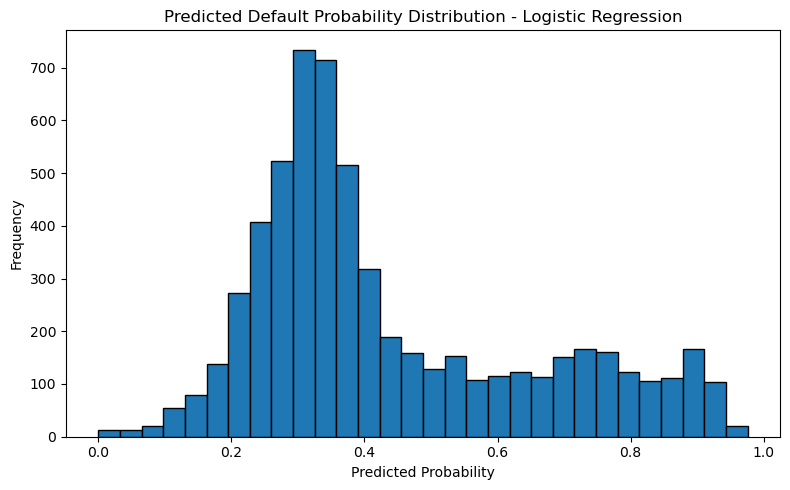


Project completed successfully.


In [17]:
# ============================================================
# 13. OPTIONAL: SIMPLE ROC-AUC READY VISUAL CHECK
# ============================================================
# Distribution of predicted default probabilities
plt.figure(figsize=(8, 5))
plt.hist(y_prob_lr, bins=30, edgecolor="black")
plt.title("Predicted Default Probability Distribution - Logistic Regression")
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print("\nProject completed successfully.")